# 05 YOLOv8s Training 

In [9]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from ultralytics import YOLO

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

In [ ]:
#paths
BASE_DIR     = Path("../")
VAL_DIR      = BASE_DIR / "data/statefarm_subject_split/val"
TRAIN_DIR    = BASE_DIR / "data/statefarm_subject_split/train"
REPORTS_DIR  = BASE_DIR / "reports"
MODELS_DIR   = BASE_DIR / "models"
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

#YOLOv8n weights for comparison
YOLON_WEIGHTS = Path("runs/yolov8n_statefarm/weights/best.pt")

#YOLOv8s output path
YOLOS_PROJECT = "runs/yolov8s_statefarm_full"
YOLOS_NAME    = "yolov8s_subject_split"

#class labels
CLASS_NAMES = [
    "c0: Safe Driving",     "c1: Texting (Right)",
    "c2: Phone (Right)",    "c3: Texting (Left)",
    "c4: Phone (Left)",     "c5: Radio",
    "c6: Drinking",         "c7: Reaching Behind",
    "c8: Hair/Makeup",      "c9: Talking to Passenger"
]
SHORT_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]
NUM_CLASSES  = 10

In [ ]:
def collect_yolo_predictions(model, val_dir):
    y_true, y_pred, y_probs = [], [], []
    val_path = Path(val_dir)
    class_folders = sorted([d for d in val_path.iterdir() if d.is_dir()])

    t_start = time.time()
    n_imgs  = 0

    for true_idx, folder in enumerate(class_folders):
        imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
        for img_path in imgs:
            result   = model.predict(str(img_path), imgsz=224, verbose=False)[0]
            probs    = result.probs.data.cpu().numpy()
            pred_idx = int(np.argmax(probs))
            y_true.append(true_idx)
            y_pred.append(pred_idx)
            y_probs.append(probs)
            n_imgs  += 1
        print(f"  [{folder.name}] done — {len(imgs)} images")

    inf_time_ms = ((time.time() - t_start) / n_imgs) * 1000
    return np.array(y_true), np.array(y_pred), np.array(y_probs), inf_time_ms


def compute_metrics(y_true, y_pred, y_probs, model_name, inf_time_ms, model_size_mb):

    acc      = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    macro_p  = precision_score(y_true, y_pred, average="macro")
    macro_r  = recall_score(y_true, y_pred, average="macro")

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        auc_scores.append(auc(fpr, tpr))
    mean_auc = np.mean(auc_scores)

    return {
        "Model":           model_name,
        "Top 1 Acc ":       round(acc * 100, 2),
        "Macro F1":        round(macro_f1, 4),
        "Macro Precision": round(macro_p, 4),
        "Macro Recall":    round(macro_r, 4),
        "Mean AUC":        round(mean_auc, 4),
        "Inf. Time (ms)": round(inf_time_ms, 2),
        "Size (MB)":       round(model_size_mb, 1),
    }, auc_scores


def get_model_size_mb(path):
    p = Path(path)
    return p.stat().st_size / (1024 * 1024) if p.exists() else 0.0

In [ ]:

print(f"Data    : {BASE_DIR / 'data/statefarm_subject_split'}")
print(f"Project : {YOLOS_PROJECT}/{YOLOS_NAME}")
yolos_model = YOLO("yolov8s-cls.pt")  # retrained YOLOv8s classification weights

yolos_results = yolos_model.train(
    data     = str(BASE_DIR / "data/statefarm_subject_split"),
    epochs   = 50,
    imgsz    = 224,
    batch    = 32,
    patience = 15,       #gives YOLOv8s more time to converge
    project  = YOLOS_PROJECT,
    name     = YOLOS_NAME,
    exist_ok = True,
    verbose  = True,
)

print("\nYOLOv8s training complete")

Starting YOLOv8s full 50-epoch training...
Data    : ../data/statefarm_subject_split
Project : runs/yolov8s_statefarm_full/yolov8s_subject_split_50ep
This may take 20–40 minutes on Apple M5 ⏳

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.9 torch-2.10.0 CPU (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/statefarm_subject_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=

In [ ]:
# Load best weights from training
YOLOS_WEIGHTS = Path(f"{YOLOS_PROJECT}/{YOLOS_NAME}/weights/best.pt")
print(f"Loading weights from: {YOLOS_WEIGHTS}")
print(f"File exists: {YOLOS_WEIGHTS.exists()}")

yolos_eval = YOLO(str(YOLOS_WEIGHTS))
yolos_size_mb = get_model_size_mb(YOLOS_WEIGHTS)

print("\nRunning inference on validation set")
y_true_s, y_pred_s, y_probs_s, yolos_inf_time = collect_yolo_predictions(yolos_eval, VAL_DIR)

yolos_metrics, yolos_auc_scores = compute_metrics(
    y_true_s, y_pred_s, y_probs_s,
    "YOLOv8s", yolos_inf_time, yolos_size_mb
)

Loading weights from: runs/classify/runs/yolov8s_statefarm_full/yolov8s_subject_split_50ep/weights/best.pt
File exists: True

Running inference on validation set...
  [c0] done — 457 images
  [c1] done — 355 images
  [c2] done — 376 images
  [c3] done — 406 images
  [c4] done — 389 images
  [c5] done — 401 images
  [c6] done — 394 images
  [c7] done — 378 images
  [c8] done — 324 images
  [c9] done — 366 images


In [19]:

yolon_eval = YOLO(str(YOLON_WEIGHTS))
yolon_size_mb = get_model_size_mb(YOLON_WEIGHTS)


y_true_n, y_pred_n, y_probs_n, yolon_inf_time = collect_yolo_predictions(yolon_eval, VAL_DIR)

yolon_metrics, yolon_auc_scores = compute_metrics(
    y_true_n, y_pred_n, y_probs_n,
    "YOLOv8n", yolon_inf_time, yolon_size_mb
)

for k, v in yolon_metrics.items():
    if k != "Model":
        print(f"  {k:<20} : {v}")

  [c0] done — 457 images
  [c1] done — 355 images
  [c2] done — 376 images
  [c3] done — 406 images
  [c4] done — 389 images
  [c5] done — 401 images
  [c6] done — 394 images
  [c7] done — 378 images
  [c8] done — 324 images
  [c9] done — 366 images
  Top1 Acc             : 92.3
  Macro F1             : 0.922
  Macro Precision      : 0.9243
  Macro Recall         : 0.9238
  Mean AUC             : 0.9941
  Inf. Time (ms)       : 4.76
  Size (MB)            : 2.8


In [22]:
df_cmp = pd.DataFrame([yolon_metrics, yolos_metrics]).set_index("Model")

print(df_cmp[["Top1 Acc ", "Macro F1", "Mean AUC", "Inf. Time (ms)", "Size (MB)"]].to_string())

# Save
df_cmp.to_csv(REPORTS_DIR / "yolov8n_vs_yolov8s.csv")
print(f"\nSaved to {REPORTS_DIR / 'yolov8n_vs_yolov8s.csv'}")

         Top1 Acc   Macro F1  Mean AUC  Inf. Time (ms)  Size (MB)
Model                                                            
YOLOv8n      92.30    0.9220    0.9941            4.76        2.8
YOLOv8s      90.51    0.8983    0.9874            7.64       29.3

Saved to ../reports/yolov8n_vs_yolov8s.csv


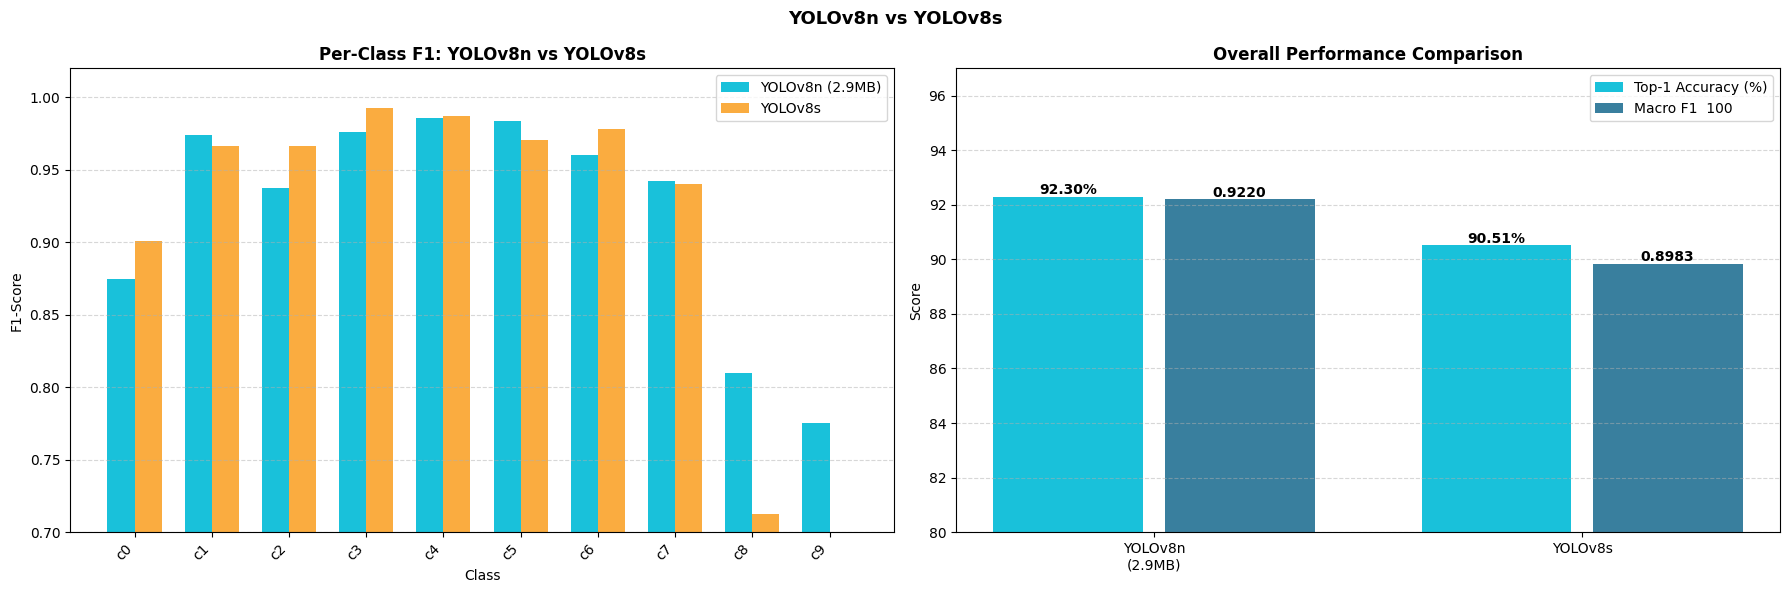

Saved to ../reports/yolov8n_vs_yolov8s_comparison.png 


In [30]:

TEAL  = "#00bbd6"
AMBER = "#faa32b"
NAVY  = "#237194"

f1_n = f1_score(y_true_n, y_pred_n, average=None)
f1_s = f1_score(y_true_s, y_pred_s, average=None)

x     = np.arange(NUM_CLASSES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Per class F1
axes[0].bar(x - width/2, f1_n, width, label="YOLOv8n (2.9MB)", color=TEAL,  alpha=0.9)
axes[0].bar(x + width/2, f1_s, width, label="YOLOv8s ",  color=AMBER, alpha=0.9)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("Per-Class F1: YOLOv8n vs YOLOv8s", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(SHORT_NAMES, rotation=45, ha="right")
axes[0].set_ylim(0.7, 1.02)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Overall accuracy & F1
models_list = ["YOLOv8n\n(2.9MB)", "YOLOv8s\n"]
acc_vals    = [yolon_metrics["Top1 Acc "], yolos_metrics["Top1 Acc "]]
f1_vals     = [yolon_metrics["Macro F1"] * 100, yolos_metrics["Macro F1"] * 100]

bar_x = np.arange(2)
axes[1].bar(bar_x - 0.2, acc_vals, 0.35, label="Top-1 Accuracy (%)", color=TEAL,  alpha=0.9)
axes[1].bar(bar_x + 0.2, f1_vals,  0.35, label="Macro F1  100",     color=NAVY,  alpha=0.9)
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(models_list)
axes[1].set_ylim(80, 97)
axes[1].set_ylabel("Score")
axes[1].set_title("Overall Performance Comparison", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

for i, (a, f) in enumerate(zip(acc_vals, f1_vals)):
    axes[1].text(i - 0.2, a + 0.1, f"{a:.2f}%", ha="center", fontsize=10, fontweight="bold")
    axes[1].text(i + 0.2, f + 0.1, f"{f/100:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("YOLOv8n vs YOLOv8s",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_path = REPORTS_DIR / "yolov8n_vs_yolov8s_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path} ")